In [155]:
from pathlib import Path

root = Path("/Users/ct6g18/Downloads/gridded")

output_dir = Path("/Users/ct6g18/Julia/GLODAP_Section_Gridder/data/masks")

found_files = sorted([f for f in root.glob("*/*.nc")])

done_sections = sorted([f.stem for f in output_dir.glob("*.nc")])
done_fhandles = sorted([f for f in output_dir.glob("*.nc")])

files_to_do = [f for f in found_files if f.stem not in done_sections]

files_to_do

[]

In [149]:
import xarray as xr
# Add: horz_coord attr, comments attr
# - horz_coord: latitude / longitude
# - comments: Mask for $section_name, generated by Charles turner from GO-SHIP Easy Ocean using $yearname transect.
xr.open_dataset(files_to_do[0])

<xarray.Dataset> Size: 95MB
Dimensions:                   (gridded_section: 8, longitude: 454, latitude: 1,
                               pressure: 651)
Coordinates:
  * gridded_section           (gridded_section) float64 64B 1.0 2.0 ... 7.0 8.0
  * longitude                 (longitude) float64 4kB -56.6 -56.5 ... -11.3
  * latitude                  (latitude) float64 8B -66.98
  * pressure                  (pressure) float64 5kB 0.0 10.0 ... 6.5e+03
Data variables:
    time                      (longitude, gridded_section) datetime64[ns] 29kB ...
    temperature               (pressure, latitude, longitude, gridded_section) float64 19MB ...
    practical_salinity        (pressure, latitude, longitude, gridded_section) float64 19MB ...
    oxygen                    (pressure, latitude, longitude, gridded_section) float64 19MB ...
    conservative_temperature  (pressure, latitude, longitude, gridded_section) float64 19MB ...
    absolute_salinity         (pressure, latitude, longitude, gridded_section) float64 19MB ...
Attributes: (12/36)
    program:                       GO-Ship Easy Ocean. WOCE and GO-Ship gridd...
    Conventions:                   CF-1.7 ACDD-1.3
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    title:                         Gridded CTD product from WOCE and GO-Ship ...
    date_issued:                   20230927
    abstract:                      Ship-based hydrographic data are essential...
    ...                            ...
    creator_email:                 k.katsumata@jamstec.go.jp
    lineage:                       Data were created as described at: https:/...
    citation:                      The citation in a list of references is: "...
    acknowledgement:               Data were collected and made publicly avai...
    disclaimer:                    Data, products and services from CCHDO are...
    license:                       http://creativecommons.org/licenses/by/4.0/

In [153]:
ds = xr.open_dataset(files_to_do[0])

lon: bool = True
pacific: bool = True
yr = 1990
section_no = 1
horz_coord = "longitude" if lon else "latitude"
comments_str = f"Mask for {ds.goship_woce_line_id}, generated from GO-SHIP Easy Ocean by Charles Turner using {yr} transect."

# if pacific:
#     ds["longitude"] = ds["longitude"] % 360

dates = ds["time"].mean(dim=horz_coord)


# mask = ds["absolute_salinity"] // ds["absolute_salinity"]
mask = ds["temperature"] // ds["temperature"]
print(dates.to_numpy()[section_no])
mask = mask.squeeze().isel(gridded_section=section_no).drop_vars("gridded_section")
# mask = mask.squeeze().drop_vars("gridded_section")
mask


1990-12-02T10:48:00.000000000


<xarray.DataArray 'temperature' (pressure: 651, longitude: 454)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ...,  1.,  1., nan],
       [nan, nan, nan, ...,  1.,  1., nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(651, 454))
Coordinates:
  * longitude  (longitude) float64 4kB -56.6 -56.5 -56.4 ... -11.5 -11.4 -11.3
    latitude   float64 8B -66.98
  * pressure   (pressure) float64 5kB 0.0 10.0 20.0 ... 6.49e+03 6.5e+03

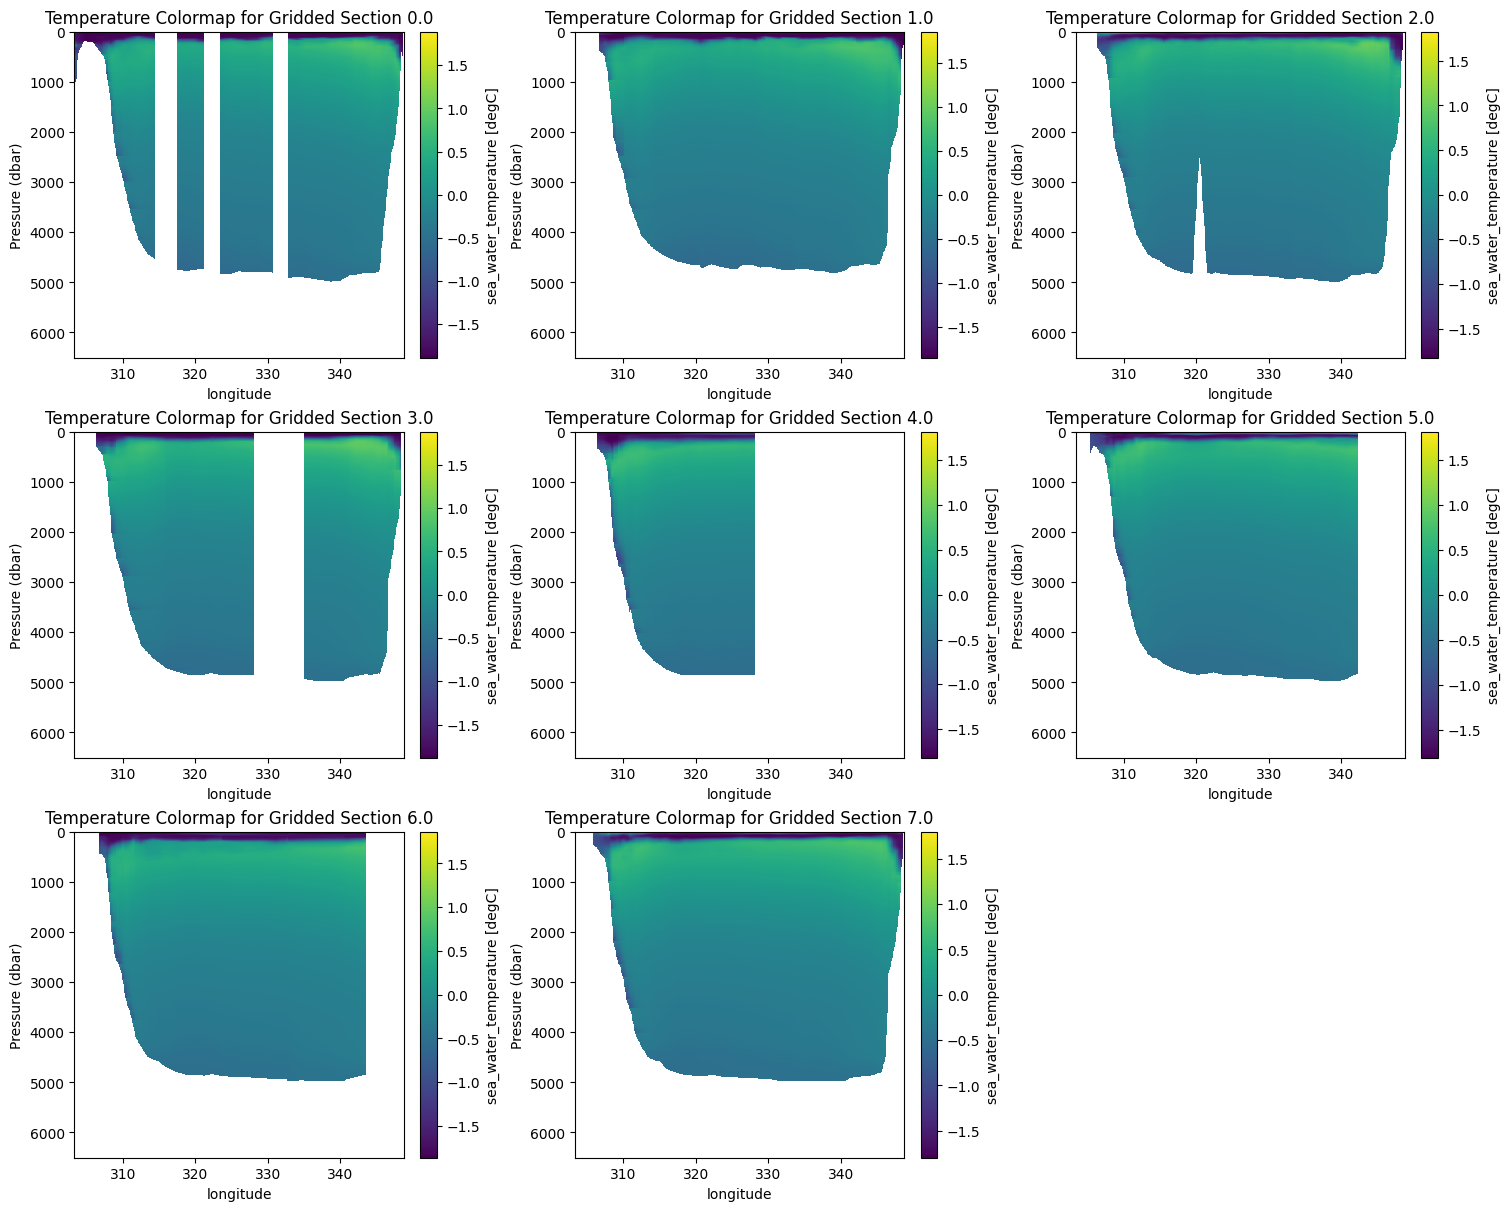

In [151]:
import matplotlib.pyplot as plt
import xarray as xr
import math

ds = xr.open_dataset(files_to_do[0])

if pacific:
    ds["longitude"] = ds["longitude"] % 360

# Number of sections
sections = ds['temperature']['gridded_section']
num_sections = len(sections)

# Calculate rows and columns for tiling
cols = math.ceil(math.sqrt(num_sections))
rows = math.ceil(num_sections / cols)

# Create a figure with subplots
fig, axes = plt.subplots(
    nrows=rows, 
    ncols=cols, 
    figsize=(5 * cols, 4 * rows), 
    constrained_layout=True
)

# Flatten axes for easy iteration
if not isinstance(axes, plt.Axes):
    axes = axes.flatten()

# Iterate over each gridded_section and plot
if isinstance(axes,plt.Axes):
    section_data = ds['temperature']
    fig, ax = section_data.squeeze().plot.pcolormesh(
        x=horz_coord, 
        y='pressure', 
        cmap='viridis', 
        shading='auto', 
        add_colorbar=True
    )
    ax.invert_yaxis()  # Invert y-axis for pressure
    ax.set_title(f"Temperature Colormap for Gridded Section 0")
    ax.set_xlabel(horz_coord)
    ax.set_ylabel('Pressure (dbar)')

for ax, section in zip(axes, sections):
    section_data = ds['temperature'].sel(gridded_section=section)
    section_data.squeeze().plot.pcolormesh(
        ax=ax, 
        x=horz_coord, 
        y='pressure', 
        cmap='viridis', 
        shading='auto', 
        add_colorbar=True
    )
    ax.invert_yaxis()  # Invert y-axis for pressure
    ax.set_title(f"Temperature Colormap for Gridded Section {section.values - 1}")
    ax.set_xlabel(horz_coord)
    ax.set_ylabel('Pressure (dbar)')

# Hide unused subplots
for ax in axes[num_sections:]:
    ax.set_visible(False)

plt.show()

In [154]:
mask.attrs = ds.attrs
mask.attrs["horz_coord"] = horz_coord
mask.attrs["comments_str"] = comments_str

mask.to_netcdf(output_dir / f"{mask.goship_woce_line_id.lower()}.nc")